# Feature Engineering: User-level фічі

Expanding window фічі по попереднім TX кожного юзера. Без data leakage.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.tree import DecisionTreeClassifier, export_text
warnings.filterwarnings('ignore')

DATA_PATH = 'int-20-h-2026-final-task/'

df = pd.read_csv(DATA_PATH + 'train_data_fixed.csv', parse_dates=['order_created_at'], nrows=1_000_000)
print(f'Train: {df.shape}')

Train: (1000000, 42)


In [38]:
# Фільтруємо + сортуємо
df_u = df[df['customer_account_id'].notna()].copy()
df_u = df_u.sort_values(['customer_account_id', 'order_created_at']).reset_index(drop=True)
print(f'Рядків з customer_account_id: {len(df_u):,}')

Рядків з customer_account_id: 934,819


## 1. Генерація user-level expanding фіч

In [39]:
%%time
g = df_u.groupby('customer_account_id', sort=False)

# --- 1. Історія успішності ---
df_u['user_prev_tx_count'] = g.cumcount()  # 0-based = кількість попередніх TX
df_u['_cum_success'] = g['is_success'].transform(lambda x: x.cumsum().shift(1))
df_u['user_prev_ar'] = df_u['_cum_success'] / df_u['user_prev_tx_count']
df_u['user_prev_fail_count'] = df_u['user_prev_tx_count'] - df_u['_cum_success']

print('1. Історія успішності — done')

1. Історія успішності — done
CPU times: user 54 s, sys: 3.22 s, total: 57.2 s
Wall time: 1min 2s


In [40]:
%%time
# --- 2. Amount патерни ---
df_u['_cum_amount'] = g['amount_scaled'].transform(lambda x: x.cumsum().shift(1))
df_u['user_prev_mean_amount'] = df_u['_cum_amount'] / df_u['user_prev_tx_count']
df_u['user_amount_ratio'] = df_u['amount_scaled'] / df_u['user_prev_mean_amount']
df_u['user_amount_ratio'] = df_u['user_amount_ratio'].replace([np.inf, -np.inf], np.nan)

# Expanding std через E[X^2] - E[X]^2
df_u['_cum_amount_sq'] = g['amount_scaled'].transform(lambda x: (x**2).cumsum().shift(1))
df_u['user_prev_std_amount'] = np.sqrt(
    (df_u['_cum_amount_sq'] / df_u['user_prev_tx_count'] - df_u['user_prev_mean_amount']**2).clip(lower=0)
)

print('2. Amount патерни — done')

2. Amount патерни — done
CPU times: user 1min 42s, sys: 5.66 s, total: 1min 48s
Wall time: 1min 51s


In [41]:
%%time
# --- 3. Географія ---
df_u['_prev_ip'] = g['ip_country'].shift(1)
df_u['user_ip_changed'] = (df_u['_prev_ip'].notna() & (df_u['ip_country'] != df_u['_prev_ip'])).astype(int)
df_u['is_cross_border'] = (df_u['ip_country'] != df_u['card_country']).astype(int)

# Кумулятивна кількість змін IP
df_u['user_prev_ip_changes'] = g['user_ip_changed'].transform(lambda x: x.cumsum().shift(1)).fillna(0)

# Cross-border rate
df_u['user_prev_cross_border_rate'] = g['is_cross_border'].transform(lambda x: x.cumsum().shift(1)) / df_u['user_prev_tx_count']

# Expanding nunique IP countries
df_u['user_ip_is_new'] = (~g['ip_country'].transform(lambda x: x.duplicated(keep='first'))).astype(int)
df_u['user_prev_n_ip_countries'] = g['user_ip_is_new'].transform(lambda x: x.cumsum().shift(1)).fillna(0)

print('3. Географія — done')

3. Географія — done
CPU times: user 3min 18s, sys: 7.68 s, total: 3min 25s
Wall time: 3min 30s


In [42]:
%%time
# --- 4. Часові патерни ---
df_u['_prev_time'] = g['order_created_at'].shift(1)
df_u['user_time_since_last_tx'] = (df_u['order_created_at'] - df_u['_prev_time']).dt.total_seconds()
df_u['user_time_since_last_tx_hours'] = df_u['user_time_since_last_tx'] / 3600

print('4. Часові патерни — done')

4. Часові патерни — done
CPU times: user 17.8 ms, sys: 13.6 ms, total: 31.4 ms
Wall time: 49.9 ms


In [43]:
%%time
# --- 5. Expanding nunique ---
for col, name in [('psp_id', 'psp'), ('shop_id', 'shop'),
                   ('currency', 'currency'), ('cardbrand', 'cardbrand')]:
    is_new = (~g[col].transform(lambda x: x.duplicated(keep='first'))).astype(int)
    df_u[f'user_prev_n_{name}'] = g[col].transform(
        lambda x: (~x.duplicated(keep='first')).astype(int).cumsum().shift(1)
    ).fillna(0)

print('5. Expanding nunique — done')

5. Expanding nunique — done
CPU times: user 8min 49s, sys: 17.9 s, total: 9min 7s
Wall time: 9min 17s


In [44]:
%%time
# --- 6. Тип поведінки (expanding rates) ---
df_u['_is_token'] = (df_u['transaction_type'] == 'token').astype(int)
df_u['user_prev_recurring_rate'] = g['_is_token'].transform(lambda x: x.cumsum().shift(1)) / df_u['user_prev_tx_count']

df_u['_is_sec'] = df_u['is_secured'].astype(int)
df_u['user_prev_secured_rate'] = g['_is_sec'].transform(lambda x: x.cumsum().shift(1)) / df_u['user_prev_tx_count']

df_u['_is_sub'] = df_u['is_subscription'].astype(int)
df_u['user_prev_subscription_rate'] = g['_is_sub'].transform(lambda x: x.cumsum().shift(1)) / df_u['user_prev_tx_count']

df_u['user_prev_mean_cascade'] = g['cascade_number'].transform(lambda x: x.cumsum().shift(1)) / df_u['user_prev_tx_count']

print('6. Тип поведінки — done')

6. Тип поведінки — done
CPU times: user 3min 23s, sys: 8.1 s, total: 3min 31s
Wall time: 3min 37s


In [ ]:
%%time
# --- 7. Fail streak (numpy vectorized per user) ---
# df_u = df[df['customer_account_id'].notna()].copy()
# df_u = df_u.sort_values(['customer_account_id', 'order_created_at']).reset_index(drop=True)
# g = df_u.groupby('customer_account_id', sort=False)

# df_u['user_prev_tx_count'] = g.cumcount() 


df_u['user_is_new'] = (df_u['user_prev_tx_count'] == 0).astype(int)

def calc_fail_streak_vec(is_success_arr):
    streak = np.zeros(len(is_success_arr), dtype=np.int32)
    current = 0
    for i in range(len(is_success_arr)):
        streak[i] = current
        if is_success_arr[i] == 0 or np.isnan(is_success_arr[i]):
            current += 1
        else:
            current = 0
    return streak

df_u['user_prev_fail_streak'] = g['is_success'].transform(
    lambda x: calc_fail_streak_vec(x.values)
)

print('7. Fail streak — done')

7. Fail streak — done
CPU times: user 19.9 s, sys: 1.27 s, total: 21.2 s
Wall time: 22 s


In [46]:
# Прибираємо тимчасові колонки
tmp_cols = [c for c in df_u.columns if c.startswith('_')]
df_u.drop(columns=tmp_cols, inplace=True)

user_features = sorted([c for c in df_u.columns if c.startswith('user_') or c == 'is_cross_border'])
print(f'Згенеровано {len(user_features)} user-level фіч:')
for f in user_features:
    print(f'  {f}')

Згенеровано 25 user-level фіч:
  is_cross_border
  user_agent
  user_amount_ratio
  user_ip_changed
  user_ip_is_new
  user_is_new
  user_prev_ar
  user_prev_cross_border_rate
  user_prev_fail_count
  user_prev_fail_streak
  user_prev_ip_changes
  user_prev_mean_amount
  user_prev_mean_cascade
  user_prev_n_cardbrand
  user_prev_n_currency
  user_prev_n_ip_countries
  user_prev_n_psp
  user_prev_n_shop
  user_prev_recurring_rate
  user_prev_secured_rate
  user_prev_std_amount
  user_prev_subscription_rate
  user_prev_tx_count
  user_time_since_last_tx
  user_time_since_last_tx_hours


In [47]:
# Попередній error_code юзера
g = df_u.groupby('customer_account_id', sort=False)
df_u['user_prev_error_code'] = g['error_code'].shift(1)
print(f'user_prev_error_code — done')
print(f'NaN: {df_u["user_prev_error_code"].isna().sum():,} ({df_u["user_prev_error_code"].isna().mean():.2%})')
print(f'Top-5 значень:')
print(df_u['user_prev_error_code'].value_counts().head())

user_prev_error_code — done
NaN: 849,378 (90.86%)
Top-5 значень:
user_prev_error_code
3.10      21288
3.08      19124
3.02      14578
3.04       4221
3.02.2     3361
Name: count, dtype: int64


In [50]:
# Decision Tree на train, тільки TX з історією
from sklearn.metrics import f1_score, classification_report

df_model = df_u[df_u['user_is_new'] == 0].copy()
print(f'TX для моделі (з історією): {len(df_model):,} з {len(df_u):,}')

# User-level фічі
user_feature_cols = [
    'user_prev_tx_count', 'user_prev_ar', 'user_prev_fail_count', 'user_prev_fail_streak',
    'user_prev_mean_amount', 'user_prev_std_amount', 'user_amount_ratio',
    'user_ip_changed', 'user_prev_ip_changes', 'is_cross_border',
    'user_prev_cross_border_rate', 'user_prev_n_ip_countries', 'user_ip_is_new',
    'user_time_since_last_tx', 'user_time_since_last_tx_hours',
    'user_prev_n_psp', 'user_prev_n_shop', 'user_prev_n_currency', 'user_prev_n_cardbrand',
    'user_prev_recurring_rate', 'user_prev_secured_rate', 'user_prev_subscription_rate',
    'user_prev_mean_cascade',
]

num_feature_cols = [
    'amount_scaled', 'cascade_number', 'card_exp_relative_scaled',
    'is_secured', 'is_subscription', 'is_payfac', 'settle_interval',
]

cat_feature_cols = [
    'bank', 'card_country', 'ip_country', 'cardbrand', 'cardtype',
    'card_pan_type', 'payment_source', 'platform', 'transaction_type',
    'currency', 'psp_id', 'mcc_id', 'antifraud_decision',
    'traffic_source', 'acquiring_bank_id', 'merchant_token_type',
    'user_prev_error_code',
]

# Encode категоріальні (top-N + other для обмеження розмірності)
for col in cat_feature_cols:
    top_vals = df_model[col].value_counts().head(20).index
    df_model[f'{col}_enc'] = df_model[col].fillna('MISSING').where(
        df_model[col].fillna('MISSING').isin(top_vals.tolist() + ['MISSING']), 'OTHER'
    )

cat_encoded_cols = [f'{c}_enc' for c in cat_feature_cols]
df_enc = pd.get_dummies(df_model, columns=cat_encoded_cols, drop_first=False)

# Збираємо всі фічі
all_feature_cols = user_feature_cols + num_feature_cols
dummy_cols = [c for c in df_enc.columns if any(c.startswith(f'{cat}_enc_') for cat in cat_feature_cols)]
all_feature_cols += dummy_cols

print(f'Всього фіч: {len(all_feature_cols)} (user: {len(user_feature_cols)}, num: {len(num_feature_cols)}, cat dummies: {len(dummy_cols)})')

X = df_enc[all_feature_cols].fillna(-1).values
y = df_enc['is_success'].values

dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=500, random_state=42)
dt.fit(X, y)
y_pred = dt.predict(X)

print(f'\nAccuracy: {dt.score(X, y):.4f}')
print(f'F1 (macro):  {f1_score(y, y_pred, average="macro"):.4f}')
print(f'F1 (class 0): {f1_score(y, y_pred, pos_label=0):.4f}')
print(f'F1 (class 1): {f1_score(y, y_pred, pos_label=1):.4f}')
print(f'\n{classification_report(y, y_pred, target_names=["fail (0)", "success (1)"])}')

tree_text = export_text(dt, feature_names=all_feature_cols, max_depth=6)
print(f'Дерево рішень:')
print(tree_text[:5000])

TX для моделі (з історією): 118,007 з 934,819
Всього фіч: 272 (user: 23, num: 7, cat dummies: 242)

Accuracy: 0.8235
F1 (macro):  0.7653
F1 (class 0): 0.8822
F1 (class 1): 0.6485

              precision    recall  f1-score   support

    fail (0)       0.84      0.92      0.88     84331
 success (1)       0.75      0.57      0.65     33676

    accuracy                           0.82    118007
   macro avg       0.80      0.75      0.77    118007
weighted avg       0.82      0.82      0.82    118007

Дерево рішень:
|--- user_prev_fail_streak <= 0.50
|   |--- cascade_number <= 1.50
|   |   |--- user_amount_ratio <= 1.15
|   |   |   |--- user_prev_mean_cascade <= 1.31
|   |   |   |   |--- user_prev_ar <= 0.56
|   |   |   |   |   |--- user_prev_ar <= 0.46
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- user_prev_ar >  0.46
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- user_prev_ar >  0.56
|   |   |   |   |   |--- user_time_since_last_tx_hours <= 0.09
|   |   |

In [51]:
df_u['user_prev_error_code'].unique()

<StringArray>
[     nan,   '3.02',   '3.10',   '3.08',   '4.03',   '2.08', '3.02.2',
   '4.05',   '3.05',   '4.01',   '3.12',   '3.04', '7.03.1',   '4.04',
 '7.07.1',   '3.03',   '2.02',   '0.01',   '2.15',   '2.01',   '2.06',
   '1.01',   '5.08', '3.03.2', '2.12.1',   '3.07',   '5.01',   '6.03',
 '3.04.2', '4.02.2', '2.08.2',   '3.01',   '2.03', '4.03.2',   '0.03',
 '2.06.2', '3.01.2', '6.03.1',   '2.09',   '3.11', '2.01.2',   '7.06',
 '5.08.2', '2.09.2', '5.02.2', '3.05.2',   '5.10',   '5.04',   '4.02',
 '4.04.2',   '2.12', '5.01.1',   '6.02',   '2.11',   '0.02',   '5.02',
   '6.01',   '4.06',   '5.03',   '7.01',   '4.08',   '5.06']
Length: 62, dtype: str

## 2. Decision Tree для валідації фіч

In [52]:
# Decision Tree на train, тільки TX з історією
from sklearn.metrics import f1_score, classification_report

df_train = df_u[df_u['is_success'].notna()].copy()  # тільки train (test has NaN)
df_model = df_train[df_train['user_is_new'] == 0].copy()
print(f'TX для моделі (з історією): {len(df_model):,} з {len(df_train):,}')

# User-level фічі
user_feature_cols = [
    'user_prev_tx_count', 'user_prev_ar', 'user_prev_fail_count', 'user_prev_fail_streak',
    'user_prev_mean_amount', 'user_prev_std_amount', 'user_amount_ratio',
    'user_ip_changed', 'user_prev_ip_changes', 'is_cross_border',
    'user_prev_cross_border_rate', 'user_prev_n_ip_countries', 'user_ip_is_new',
    'user_time_since_last_tx', 'user_time_since_last_tx_hours',
    'user_prev_n_psp', 'user_prev_n_shop', 'user_prev_n_currency', 'user_prev_n_cardbrand',
    'user_prev_recurring_rate', 'user_prev_secured_rate', 'user_prev_subscription_rate',
    'user_prev_mean_cascade',
]

num_feature_cols = [
    'amount_scaled', 'cascade_number', 'card_exp_relative_scaled',
    'is_secured', 'is_subscription', 'is_payfac', 'settle_interval',
]

cat_feature_cols = [
    'bank', 'card_country', 'ip_country', 'cardbrand', 'cardtype',
    'card_pan_type', 'payment_source', 'platform', 'transaction_type',
    'currency', 'psp_id', 'mcc_id', 'antifraud_decision',
    'traffic_source', 'acquiring_bank_id', 'merchant_token_type',
    'user_prev_error_code',
]

# Encode категоріальні (top-N + other для обмеження розмірності)
for col in cat_feature_cols:
    top_vals = df_model[col].value_counts().head(20).index
    df_model[f'{col}_enc'] = df_model[col].fillna('MISSING').where(
        df_model[col].fillna('MISSING').isin(top_vals.tolist() + ['MISSING']), 'OTHER'
    )

cat_encoded_cols = [f'{c}_enc' for c in cat_feature_cols]
df_enc = pd.get_dummies(df_model, columns=cat_encoded_cols, drop_first=False)

# Збираємо всі фічі
all_feature_cols = user_feature_cols + num_feature_cols
dummy_cols = [c for c in df_enc.columns if any(c.startswith(f'{cat}_enc_') for cat in cat_feature_cols)]
all_feature_cols += dummy_cols

print(f'Всього фіч: {len(all_feature_cols)} (user: {len(user_feature_cols)}, num: {len(num_feature_cols)}, cat dummies: {len(dummy_cols)})')

X = df_enc[all_feature_cols].fillna(-1).values
y = df_enc['is_success'].values

dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=500, random_state=42)
dt.fit(X, y)
y_pred = dt.predict(X)

print(f'\nAccuracy: {dt.score(X, y):.4f}')
print(f'F1 (macro):  {f1_score(y, y_pred, average="macro"):.4f}')
print(f'F1 (class 0): {f1_score(y, y_pred, pos_label=0):.4f}')
print(f'F1 (class 1): {f1_score(y, y_pred, pos_label=1):.4f}')
print(f'\n{classification_report(y, y_pred, target_names=["fail (0)", "success (1)"])}')

tree_text = export_text(dt, feature_names=all_feature_cols, max_depth=6)
print(f'Дерево рішень:')
print(tree_text[:5000])

TX для моделі (з історією): 118,007 з 934,819
Всього фіч: 272 (user: 23, num: 7, cat dummies: 242)

Accuracy: 0.8235
F1 (macro):  0.7653
F1 (class 0): 0.8822
F1 (class 1): 0.6485

              precision    recall  f1-score   support

    fail (0)       0.84      0.92      0.88     84331
 success (1)       0.75      0.57      0.65     33676

    accuracy                           0.82    118007
   macro avg       0.80      0.75      0.77    118007
weighted avg       0.82      0.82      0.82    118007

Дерево рішень:
|--- user_prev_fail_streak <= 0.50
|   |--- cascade_number <= 1.50
|   |   |--- user_amount_ratio <= 1.15
|   |   |   |--- user_prev_mean_cascade <= 1.31
|   |   |   |   |--- user_prev_ar <= 0.56
|   |   |   |   |   |--- user_prev_ar <= 0.46
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- user_prev_ar >  0.46
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- user_prev_ar >  0.56
|   |   |   |   |   |--- user_time_since_last_tx_hours <= 0.09
|   |   |

In [53]:
sum(y) / len(y)

np.float64(0.28537290160753176)

In [54]:
# Мержимо user-level фічі назад до оригінального df
user_feat_cols = [c for c in df_u.columns if c.startswith('user_') or c == 'is_cross_border']
merge_cols = ['psp_order_id'] + user_feat_cols

train_out = df.merge(df_u[merge_cols], on='psp_order_id', how='left')

print(f'Train з фічами: {train_out.shape}')
print(f'Нових фіч: {len(user_feat_cols)}')
print(f'NaN у user_prev_ar: {train_out["user_prev_ar"].isna().sum():,} ({train_out["user_prev_ar"].isna().mean():.2%})')

Train з фічами: (1000000, 68)
Нових фіч: 26
NaN у user_prev_ar: 881,993 (88.20%)


In [55]:
train_out.to_csv(DATA_PATH + 'train_with_user_features.csv', index=False)
print(f'Збережено: {DATA_PATH}train_with_user_features.csv')

Збережено: int-20-h-2026-final-task/train_with_user_features.csv


In [56]:
%%time
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, roc_auc_score

# XGBoost працює з категоріальними нативно — використовуємо label encoding замість one-hot
df_xgb = df_model.copy()

# Label encode категоріальні
cat_cols_xgb = [
    'bank', 'card_country', 'ip_country', 'cardbrand', 'cardtype',
    'card_pan_type', 'payment_source', 'platform', 'transaction_type',
    'currency', 'psp_id', 'mcc_id', 'antifraud_decision',
    'traffic_source', 'acquiring_bank_id', 'merchant_token_type',
    'user_prev_error_code',
]

for col in cat_cols_xgb:
    df_xgb[col] = df_xgb[col].fillna('MISSING').astype('category').cat.codes

# User-level + числові + label-encoded категоріальні
xgb_feature_cols = user_feature_cols + num_feature_cols + cat_cols_xgb

X_all = df_xgb[xgb_feature_cols].values
y_all = df_xgb['is_success'].values

# Train/val split (80/20)
X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

# Рахуємо scale_pos_weight для незбалансованих класів
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

y_pred_val = model.predict(X_val)
y_proba_val = model.predict_proba(X_val)[:, 1]

print(f'\n=== XGBoost Validation Results ===')
print(f'Accuracy:    {(y_pred_val == y_val).mean():.4f}')
print(f'F1 (macro):  {f1_score(y_val, y_pred_val, average="macro"):.4f}')
print(f'F1 (class 0): {f1_score(y_val, y_pred_val, pos_label=0):.4f}')
print(f'F1 (class 1): {f1_score(y_val, y_pred_val, pos_label=1):.4f}')
print(f'ROC AUC:     {roc_auc_score(y_val, y_proba_val):.4f}')
print(f'\n{classification_report(y_val, y_pred_val, target_names=["fail (0)", "success (1)"])}')

[0]	validation_0-logloss:0.65509
[50]	validation_0-logloss:0.42285
[100]	validation_0-logloss:0.41267
[150]	validation_0-logloss:0.40738
[200]	validation_0-logloss:0.40347
[250]	validation_0-logloss:0.40017
[300]	validation_0-logloss:0.39791
[350]	validation_0-logloss:0.39596
[400]	validation_0-logloss:0.39421
[450]	validation_0-logloss:0.39276
[499]	validation_0-logloss:0.39115

=== XGBoost Validation Results ===
Accuracy:    0.8278
F1 (macro):  0.7984
F1 (class 0): 0.8754
F1 (class 1): 0.7214
ROC AUC:     0.8951

              precision    recall  f1-score   support

    fail (0)       0.91      0.85      0.88     16867
 success (1)       0.67      0.78      0.72      6735

    accuracy                           0.83     23602
   macro avg       0.79      0.81      0.80     23602
weighted avg       0.84      0.83      0.83     23602

CPU times: user 10.4 s, sys: 1.21 s, total: 11.6 s
Wall time: 4.07 s


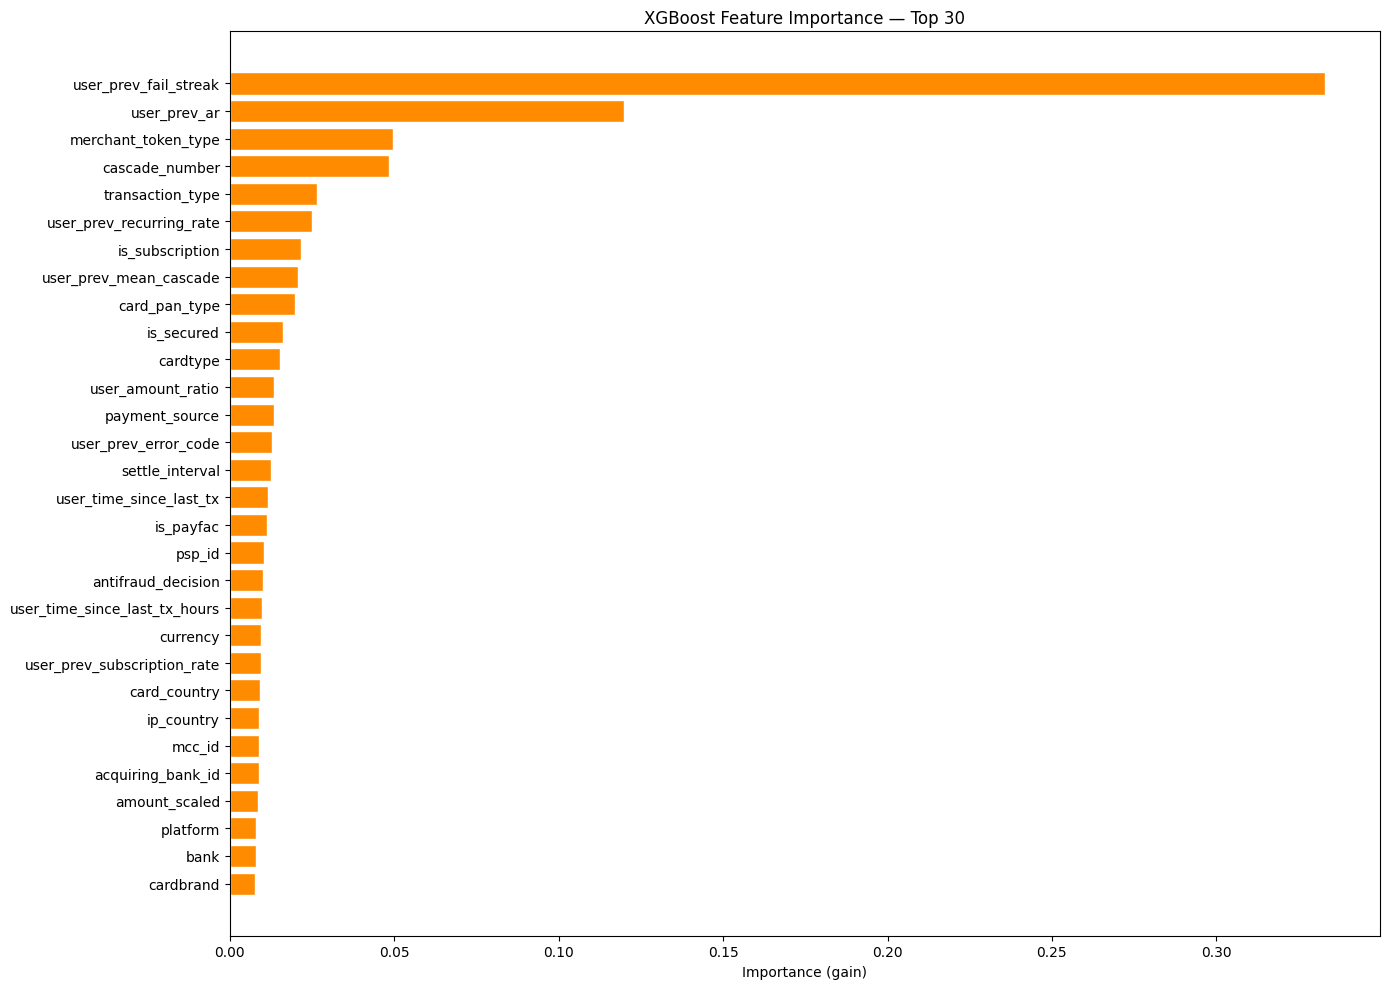


Топ-20 фічі (XGBoost):
  user_prev_fail_streak                         0.3331 ██████████████████████████████████████████████████████████████████
  user_prev_ar                                  0.1199 ███████████████████████
  merchant_token_type                           0.0496 █████████
  cascade_number                                0.0485 █████████
  transaction_type                              0.0264 █████
  user_prev_recurring_rate                      0.0251 █████
  is_subscription                               0.0215 ████
  user_prev_mean_cascade                        0.0208 ████
  card_pan_type                                 0.0199 ███
  is_secured                                    0.0161 ███
  cardtype                                      0.0154 ███
  user_amount_ratio                             0.0134 ██
  payment_source                                0.0133 ██
  user_prev_error_code                          0.0127 ██
  settle_interval                               0.01

In [57]:
# XGBoost Feature Importance
xgb_imp = pd.DataFrame({
    'feature': xgb_feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
top_xgb = xgb_imp.head(30)
ax.barh(top_xgb['feature'], top_xgb['importance'], color='darkorange', edgecolor='white')
ax.set_xlabel('Importance (gain)')
ax.set_title('XGBoost Feature Importance — Top 30')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nТоп-20 фічі (XGBoost):')
for _, row in xgb_imp.head(20).iterrows():
    bar = '█' * int(row['importance'] * 200)
    print(f"  {row['feature']:45s} {row['importance']:.4f} {bar}")